# Character Study

## Summary

In [1]:
# Code summary of below

In [2]:
!python --version

Python 3.11.4


## Import

### Libraries

In [3]:
from backend import *
#import multiprocessing as mp
#from multiprocessing import Pool, Process
#import pickle
#num_cores = int(mp.cpu_count()-2)
#print(f"Number of cores : {num_cores}")

In [4]:
%matplotlib inline

### Definitions

In [5]:
texts = '../texts/fiction/utf8/'

libCols = ['author','pub_year','title','text']
tokenOHCO = ['w_id','part_num','para_num', 'sent_num', 'token_num']
tokenCols = ['p_id', 'start', 'stop', 'text', 'token_id', 'head_id', 'rel', 'pos', 'lemma', 'anim', 'aspect', \
             'case', 'degree', 'gender', 'mood', 'number', 'person', 'tense', 'verb_form', 'voice']

In [6]:
motherTokenDf = pd.read_pickle('./proc/MotherTokendf.pkl')
#bibleTokenDf = pd.read_pickle('./proc/BibleTokenDf.pkl')
#confessionTokenDf = pd.read_pickle('./proc/ConfessionTokenDf.pkl')

In [7]:
motherTokenDf

,p_id,start,stop,text,token_id,head_id,rel,pos,lemma,anim,aspect,case,degree,gender,mood,number,person,tense,verb_form,voice
0,1,7,13,Каждый,1_1,1_2,det,DET,каждый,None,None,Acc,None,Masc,None,Sing,None,None,None,None
1,1,14,18,день,1_2,1_28,obl,NOUN,день,Inan,None,Acc,None,Masc,None,Sing,None,None,None,None
2,1,19,22,над,1_3,1_5,case,ADP,над,None,None,None,None,None,None,None,None,None,None,None
3,1,23,30,рабочей,1_4,1_5,amod,ADJ,рабочий,None,None,Ins,Pos,Fem,None,Sing,None,None,None,None
4,1,31,40,слободкой,1_5,1_28,obl,NOUN,слободка,Inan,None,Ins,None,Fem,None,Sing,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,4436,7,13,Кто-то,1_1,1_2,nsubj,PRON,кто-то,None,None,Nom,None,None,None,None,None,None,None,None
1,4436,14,21,ответил,1_2,1_0,root,VERB,ответить,None,Perf,None,None,Masc,Ind,Sing,None,Past,Fin,Act
2,4436,22,24,ей,1_3,1_2,iobj,PRON,она,None,None,Dat,None,Fem,None,Sing,3,None,None,None
3,4436,25,32,громким,1_4,1_5,amod,ADJ,громкий,None,None,Dat,Pos,None,None,Plur,None,None,None,None


In [8]:
motherTokenDf.loc[motherTokenDf.lemma == "павел"][['p_id', 'token_id']]

,p_id,token_id
7,21,2_2
20,21,3_2
2,24,1_6
51,40,5_7
8,44,1_11
...,...,...
32,4227,2_11
11,4231,2_5
59,4268,4_15
6,4295,1_7


In [9]:
pavelHead = motherTokenDf.loc[motherTokenDf.lemma == "павел"][['p_id', 'token_id']].to_dict(orient='records')
#[list(x.values()) for x in pavelHead]

In [10]:
motherTokenDf.loc[(motherTokenDf['p_id'] == 21) & (motherTokenDf.head_id.isin(["2_2", "3_2"]))].lemma

8    сын
Name: lemma, dtype: object

In [11]:
pavelHead

[{'p_id': 21, 'token_id': '2_2'},
 {'p_id': 21, 'token_id': '3_2'},
 {'p_id': 24, 'token_id': '1_6'},
 {'p_id': 40, 'token_id': '5_7'},
 {'p_id': 44, 'token_id': '1_11'},
 {'p_id': 49, 'token_id': '2_13'},
 {'p_id': 61, 'token_id': '1_7'},
 {'p_id': 67, 'token_id': '4_17'},
 {'p_id': 68, 'token_id': '1_1'},
 {'p_id': 78, 'token_id': '1_11'},
 {'p_id': 80, 'token_id': '1_10'},
 {'p_id': 88, 'token_id': '1_4'},
 {'p_id': 94, 'token_id': '1_12'},
 {'p_id': 100, 'token_id': '1_7'},
 {'p_id': 110, 'token_id': '1_1'},
 {'p_id': 137, 'token_id': '2_1'},
 {'p_id': 138, 'token_id': '2_8'},
 {'p_id': 141, 'token_id': '1_12'},
 {'p_id': 150, 'token_id': '1_6'},
 {'p_id': 163, 'token_id': '1_3'},
 {'p_id': 174, 'token_id': '1_16'},
 {'p_id': 190, 'token_id': '2_4'},
 {'p_id': 214, 'token_id': '1_2'},
 {'p_id': 219, 'token_id': '4_3'},
 {'p_id': 222, 'token_id': '1_9'},
 {'p_id': 225, 'token_id': '1_7'},
 {'p_id': 232, 'token_id': '1_9'},
 {'p_id': 233, 'token_id': '3_5'},
 {'p_id': 239, 'token_id'

In [12]:
pavelDf = pd.DataFrame()
for [p_id, head_id] in [list(x.values()) for x in pavelHead]:
    #print(f"p_id = {p_id}, head_id = {head_id}")
    pavelDf = pd.concat([pavelDf, motherTokenDf.loc[(motherTokenDf['p_id'] == p_id) & (motherTokenDf.head_id.isin([head_id]))]])

In [25]:
good_pos = ['NOUN', 'ADJ', 'VERB', 'PROPN']
pavelDf['stopword'] = ~pavelDf.pos.isin(good_pos)
TokenDfIdx = pd.Index(range(1, (pavelDf.shape[0]+1)), name='id')
pavelDf.index = TokenDfIdx# = TokenDf.set_index(['p_id', 'token_id'])

<Axes: xlabel='lemma'>

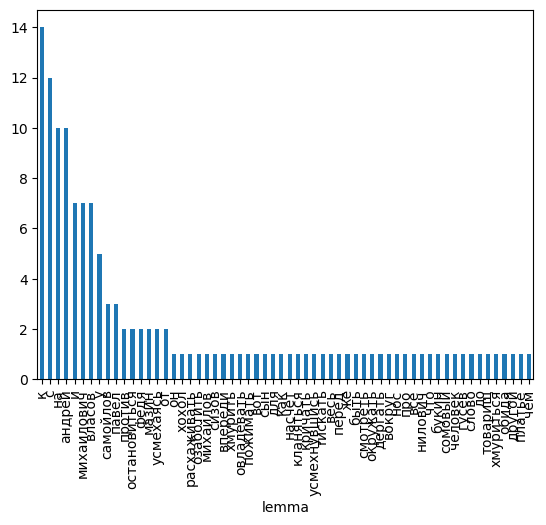

In [30]:
pavelDf.lemma.value_counts().plot(kind="bar")

In [ ]:
[expression for outer_loop in outer_iterable for inner_loop in inner_iterable]